# WNN on in vitro data only

In [1]:
here::i_am("rna_atac/dimensionality_reduction/01_WNN_MOFA.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(Seurat))
suppressPackageStartupMessages(library(batchelor))

BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 21

# Multi core using future - built in to seurat
plan("multicore", workers = 1)
options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/10_Eomes_invitro_gut/code



In [17]:
args = list()
# ATAC
args$atac_metadata = file.path(io$basedir, 'results/atac/archR/qc/sample_metadata_after_qc.txt.gz')
args$atac_lsi = file.path(io$basedir, 'results/atac/archR/dimensionality_reduction/cells/PeakMatrix/remove_ExE_cells_FALSE/batch_correction_None/lsi_nfeatures25000_dims25.txt.gz')
# RNA
args$rna_metadata = file.path(io$basedir, '/results/rna/mapping/sample_metadata_after_mapping.txt.gz')
args$rna_pca = file.path(io$basedir, 'results/rna/dimensionality_reduction/sce/batch_correction_None/pca_features2500_pcs50.txt.gz')
args$rna_sce = file.path(io$basedir, 'processed/rna/SingleCellExperiment.rds')

# outdir
args$outdir = file.path(io$basedir, 'results/rna_atac/dimensionality_reduction/')
dir.create(args$outdir, recursive=TRUE, showWarnings =FALSE)

In [46]:
##########################
## Load sample metadata ##
##########################

metadata_atac <- fread(args$atac_metadata) %>%
  .[pass_atacQC==TRUE & doublet_call==FALSE | pass_atacQC==TRUE & is.na(doublet_call)]

metadata_rna <- fread(args$rna_metadata) %>%
  .[pass_rnaQC==TRUE & doublet_call==FALSE]

#### Plotting functions

In [119]:
plot_umap = function(umap.dt){

dot_size = 5
text_size = 15
title_size = 20

p1 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=celltype)) + 
    geom_point(size=0.2) + 
    guides(colour = guide_legend(override.aes = list(size=dot_size))) + 
    scale_color_manual(values=opts$celltype.colors, name='') + 
    ggtitle('Celltype') +
    theme_void() +
    theme(text=element_text(size=text_size), 
         plot.title=element_text(size=title_size), 
         legend.position='bottom')
    
# Plot umap
p2 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=day)) + 
    geom_point(size=0.2) + 
    guides(colour = guide_legend(override.aes = list(size=dot_size))) + 
    ggtitle('Day') +
    theme_void() +
    theme(text=element_text(size=text_size), 
         plot.title=element_text(size=title_size), 
         legend.position='bottom')

# Plot umap
p3 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=genotype)) + 
    geom_point(size=0.2) + 
    scale_color_manual(values=opts$genotype.colors, name='') + 
    guides(colour = guide_legend(override.aes = list(size=dot_size))) + 
    ggtitle('Genotype') +
    theme_void() +
    theme(text=element_text(size=text_size), 
         plot.title=element_text(size=title_size), 
         legend.position='bottom')

options(repr.plot.width=20, repr.plot.height=6)
plots = ggarrange(p1,p2, p3, ncol=3)
return(plots)
}

### Load files

In [50]:
# load LSI
LSI = fread(args$atac_lsi)
metadata_atac = metadata_atac[match(LSI$cell, cell)]
summary(LSI$cell == metadata_atac$cell)

# load PCA
PCA = fread(args$rna_pca)
# metadata_rna = metadata_rna[match(PCA$cell, cell)]
summary(PCA$cell == metadata_rna$cell)

   Mode    TRUE 
logical   46547 

   Mode    TRUE 
logical   55111 

In [72]:
length(log10(metadata_atac$nFrags_atac+1))
i = 4
length(as.vector(copy(LSI)[,cell:=NULL][,..i])[[1]])

[1] 46547

[1] 46547

In [79]:
cor(x = as.vector(copy(LSI)[,cell:=NULL][,..i])[[1]], log10(metadata_atac$nFrags_atac+1))

[1] -0.04274238

In [82]:
for(i in 1:(dim(LSI)[2]-1)){
    cat(paste0('LSI ', i, ' read depth correlation: ', abs(round(cor(as.vector(copy(LSI)[,cell:=NULL][,..i])[[1]], log10(metadata_atac$nFrags_atac+1)), 3)), '\n'))
}

LSI 1 read depth correlation: 0.043
LSI 2 read depth correlation: 0.117
LSI 3 read depth correlation: 0.127
LSI 4 read depth correlation: 0.673
LSI 5 read depth correlation: 0.218
LSI 6 read depth correlation: 0.062
LSI 7 read depth correlation: 0.142
LSI 8 read depth correlation: 0.051
LSI 9 read depth correlation: 0.333
LSI 10 read depth correlation: 0.009
LSI 11 read depth correlation: 0.266
LSI 12 read depth correlation: 0.245
LSI 13 read depth correlation: 0.095
LSI 14 read depth correlation: 0.436
LSI 15 read depth correlation: 0.19
LSI 16 read depth correlation: 0.14
LSI 17 read depth correlation: 0.239
LSI 18 read depth correlation: 0.154
LSI 19 read depth correlation: 0.284
LSI 20 read depth correlation: 0.189
LSI 21 read depth correlation: 0.09
LSI 22 read depth correlation: 0.163
LSI 23 read depth correlation: 0.192
LSI 24 read depth correlation: 0.234
LSI 25 read depth correlation: 0.186


In [83]:
# Filter cells
cells_keep = intersect(metadata_atac$cell, metadata_rna$cell)
metadata_atac = metadata_atac[match(cells_keep, cell)]
metadata_rna = metadata_rna[match(cells_keep, cell)]

# metadata_atac contains all info from RNA as well as ATAC
sample_metadata = metadata_atac

# load sce
rna.sce <- load_SingleCellExperiment(args$rna_sce, normalise = TRUE, cells = sample_metadata$cell)

In [84]:
#sample_metadata = sample_metadata[,Clusters_PeakMatrix2:=NULL] # need to remove duplicated column

In [85]:
fwrite(sample_metadata, sprintf('%s/results/rna_atac/combined_metadata.txt.gz',io$basedir))

In [86]:
# format LSI
LSI = LSI[match(sample_metadata$cell, cell)] %>% 
    as.data.frame(.) %>% 
    tibble::column_to_rownames('cell') %>%
    as.matrix(.)

# format PCA
PCA = PCA[match(sample_metadata$cell, cell)] %>% 
    as.data.frame(.) %>% 
    tibble::column_to_rownames('cell') %>%
    as.matrix(.)

### WNN raw DimRedu

In [185]:
## Create Seurat object
seurat = as.Seurat(rna.sce)

# Add dimensionality reductions
seurat[["PCA"]] <- CreateDimReducObject(embeddings = PCA, key = "PC_", assay = DefaultAssay(seurat))
seurat[["LSI"]] <- CreateDimReducObject(embeddings = LSI, key = "LSI_", assay = DefaultAssay(seurat))

seurat[["PCA_scaled"]] <- CreateDimReducObject(embeddings = scale(PCA), key = "PC_", assay = DefaultAssay(seurat))
seurat[["LSI_scaled"]] <- CreateDimReducObject(embeddings = scale(LSI), key = "LSI_", assay = DefaultAssay(seurat))

Warning message:
“Cannot add objects with duplicate keys (offending key: PC_), setting key to 'pca_scaled_'”
Warning message:
“Cannot add objects with duplicate keys (offending key: LSI_), setting key to 'lsi_scaled_'”


In [186]:
seurat[["PCA_LSI"]] <- CreateDimReducObject(embeddings = cbind(scale(LSI)[,1:20], scale(PCA)[,1:15]), key = "concat_", assay = DefaultAssay(seurat))

In [187]:
seurat <- FindMultiModalNeighbors(seurat, 
                                  reduction.list = list("PCA", "LSI"), 
                                  dims.list = list(1:15, 1:20), 
                                  modality.weight.name = "RNA.weight", 
                                  verbose=FALSE
)

Warning message in FindMultiModalNeighbors(seurat, reduction.list = list("PCA", :
“The number of provided modality.weight.name is not equal to the number of modalities. RNA.weight RNA.weight are used to store the modality weights”


In [190]:
seurat <- RunUMAP(seurat, 
                  nn.name = "weighted.nn", 
                  reduction.name = "wnn.umap", 
                  reduction.key = "wnnUMAP_",
                  n.neighbors = 25,
                  min.dist = 0.25,
                  metric = 'euclidean',
                  verbose = FALSE)

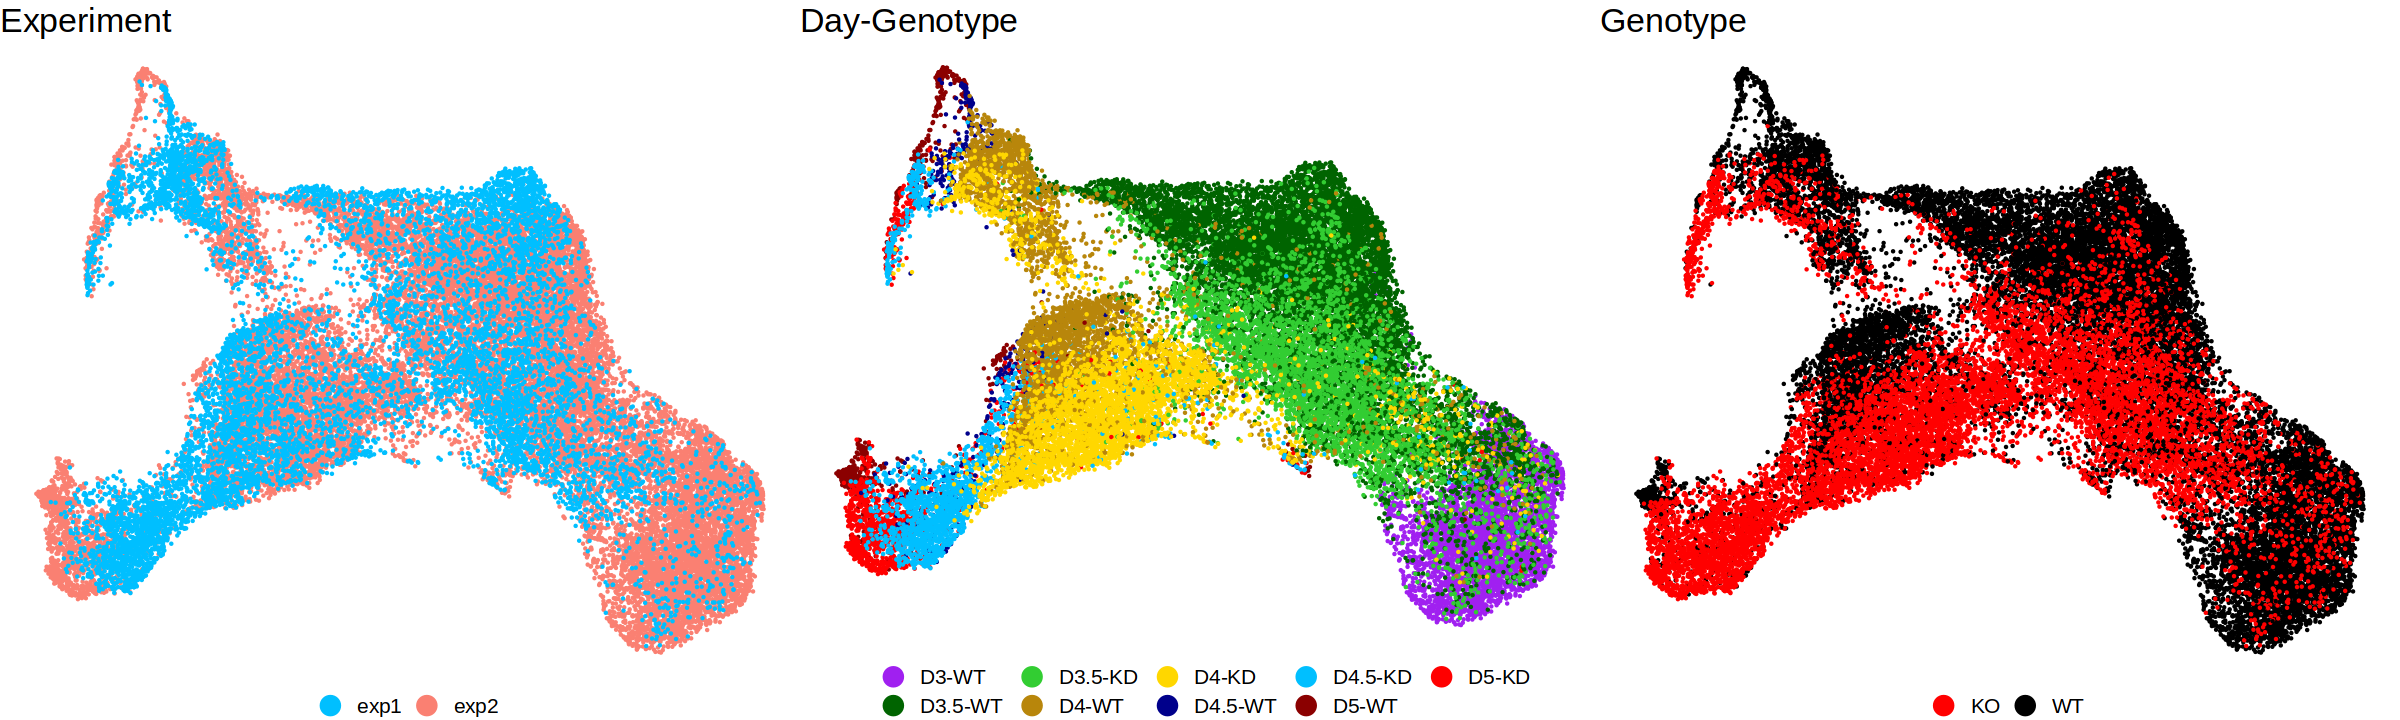

In [191]:
umap.dt = as.data.table(seurat@reductions$wnn.umap@cell.embeddings, keep.rownames=T) %>%
    setnames(c('cell', 'UMAP1', 'UMAP2')) %>%
    merge(., sample_metadata, by='cell')
plot_umap(umap.dt)

In [192]:
pdf(sprintf('%s/WNN_umap.pdf', args$outdir), width=15, height=5)
    plot_umap(umap.dt[,UMAP1:=UMAP1*-1][,UMAP2:=UMAP2*-1])
dev.off()

png 
  2

In [51]:
seurat <- FindMultiModalNeighbors(seurat, 
                                  reduction.list = list("PCA_scaled", "LSI_scaled"), 
                                  dims.list = list(1:15, 1:20), 
                                  modality.weight.name = "RNA.weight", 
                                  verbose=FALSE
)

Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from normpca_scaled_ to normpcascaled_”
Warning message:
“All keys should be one or more alphanumeric characters followed by an underscore '_', setting key to normpcascaled_”
Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from normlsi_scaled_ to normlsiscaled_”
Warning message:
“All keys should be one or more alphanumeric characters followed by an underscore '_', setting key to normlsiscaled_”
Warning message in FindMultiModalNeighbors(seurat, reduction.list = list("PCA_scaled", :
“The number of provided modality.weight.name is not equal to the number of modalities. RNA.weight RNA.weight are used to store the modality weights”


In [52]:
seurat <- RunUMAP(seurat, 
                  nn.name = "weighted.nn", 
                  reduction.name = "wnn.umap", 
                  reduction.key = "wnnUMAP_",
                  n.neighbors = 25L,
                  min.dist = 0.15,
                  metric = 'euclidean',
                  verbose = FALSE)

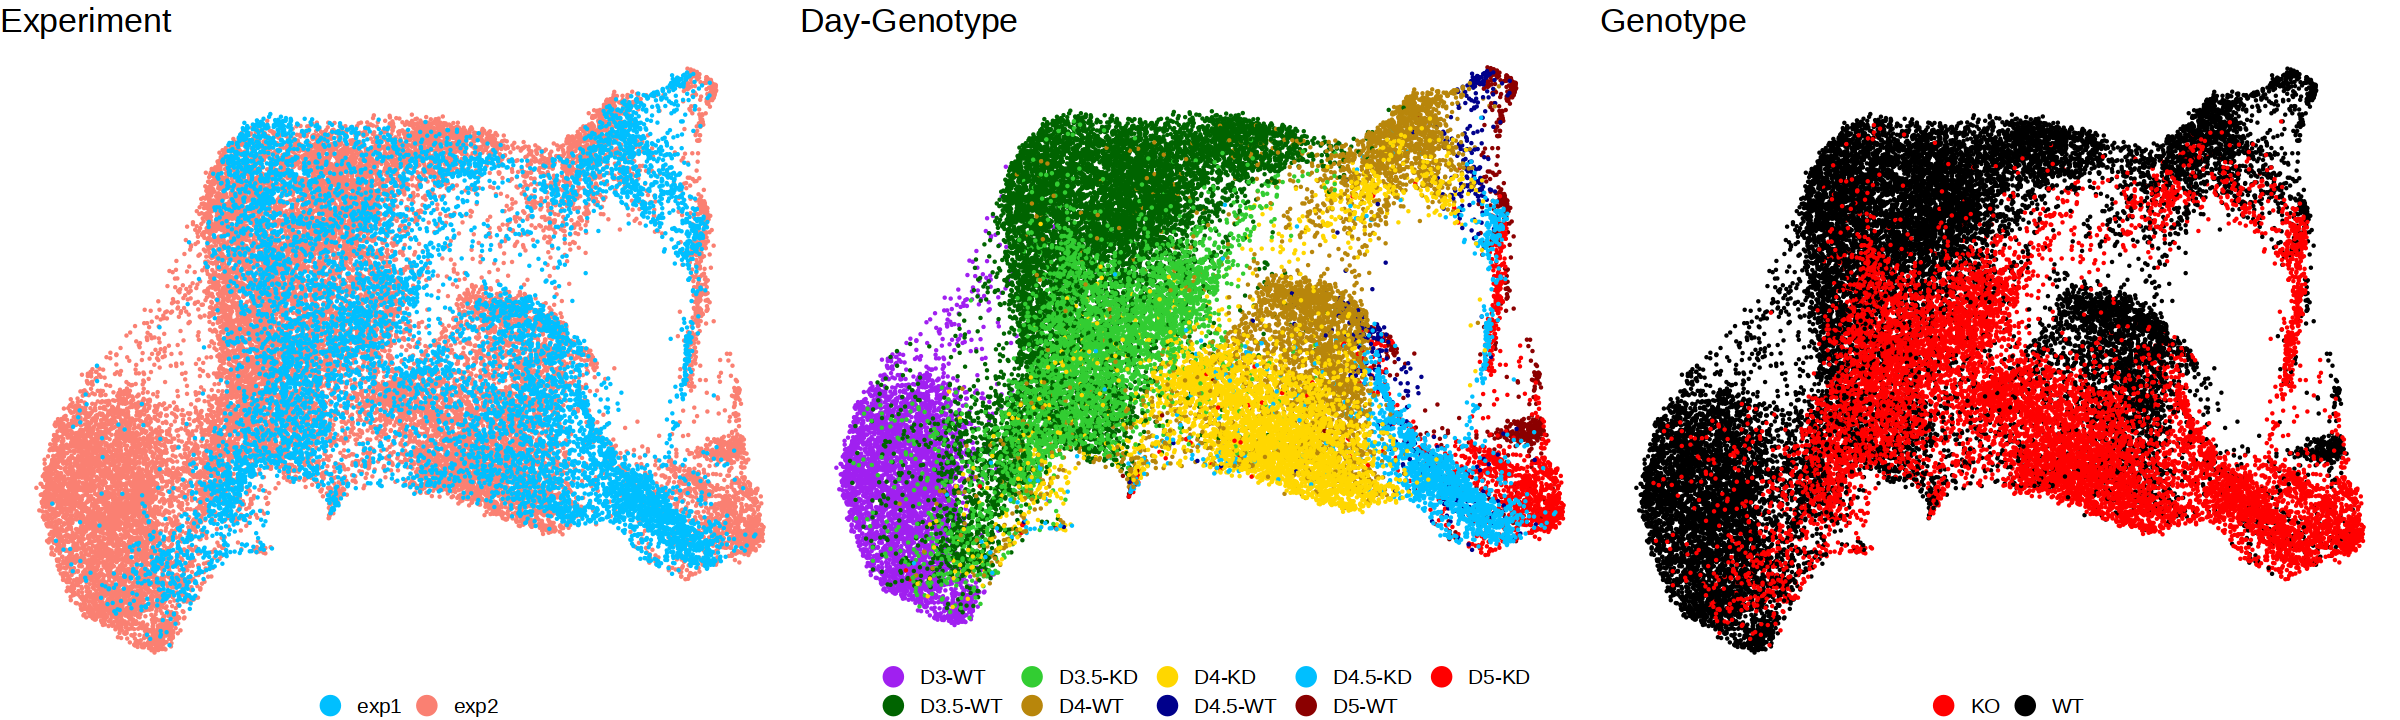

In [53]:
umap.dt = as.data.table(seurat@reductions$wnn.umap@cell.embeddings, keep.rownames=T) %>%
    setnames(c('cell', 'UMAP1', 'UMAP2')) %>%
    merge(., sample_metadata, by='cell')
plot_umap(umap.dt)

# MOFA

In [87]:
# outdir
args$outdir = file.path(io$basedir, 'results/rna_atac/dimensionality_reduction/mofa/')
dir.create(args$outdir, recursive=TRUE, showWarnings =FALSE)

In [88]:
library(MOFA2)


Attaching package: ‘MOFA2’


The following object is masked from ‘package:stats’:

    predict




In [89]:
MOFAobject <- create_mofa(list(t(scale(PCA[,1:15])), t(scale(LSI[,1:15]))))

Creating MOFA object from a list of matrices (features as rows, sample as columns)...


View names are not specified in the data, using default: view_1, view_2




In [90]:
data_opts <- get_default_data_options(MOFAobject)
head(data_opts)

$scale_views
[1] FALSE

$scale_groups
[1] FALSE

$center_groups
[1] TRUE

$use_float32
[1] TRUE

$views
[1] "view_1" "view_2"

$groups
[1] "group1"

In [91]:
model_opts <- get_default_model_options(MOFAobject)
head(model_opts)

$likelihoods
    view_1     view_2 
"gaussian" "gaussian" 

$num_factors
[1] 25

$spikeslab_factors
[1] FALSE

$spikeslab_weights
[1] FALSE

$ard_factors
[1] FALSE

$ard_weights
[1] TRUE

In [92]:
train_opts <- get_default_training_options(MOFAobject)
head(train_opts)

$maxiter
[1] 1000

$convergence_mode
[1] "fast"

$drop_factor_threshold
[1] -1

$verbose
[1] FALSE

$startELBO
[1] 1

$freqELBO
[1] 5

In [93]:
MOFAobject <- prepare_mofa(
  object = MOFAobject,
  data_options = data_opts,
  model_options = model_opts,
  training_options = train_opts
)

Checking data options...

Checking training options...

Checking model options...



In [94]:
outfile = file.path(args$outdir,"model_v1.hdf5")
MOFAobject.trained <- run_mofa(MOFAobject, outfile)

Connecting to the mofapy2 python package using reticulate (use_basilisk = FALSE)... 
    Please make sure to manually specify the right python binary when loading R with reticulate::use_python(..., force=TRUE) or the right conda environment with reticulate::use_condaenv(..., force=TRUE)
    If you prefer to let us automatically install a conda environment with 'mofapy2' installed using the 'basilisk' package, please use the argument 'use_basilisk = TRUE'


7 factors were found to explain no variance and they were removed for downstream analysis. You can disable this option by setting load_model(..., remove_inactive_factors = FALSE)



In [95]:
MOFAobject.trained = load_model(file.path(args$outdir,"model_v1.hdf5"))

7 factors were found to explain no variance and they were removed for downstream analysis. You can disable this option by setting load_model(..., remove_inactive_factors = FALSE)



In [97]:
MOFAobject.trained

Trained MOFA with the following characteristics: 
 Number of views: 2 
 Views names: view_1 view_2 
 Number of features (per view): 15 15 
 Number of groups: 1 
 Groups names: group1 
 Number of samples (per group): 46547 
 Number of factors: 18 


[[1]]

[[2]]


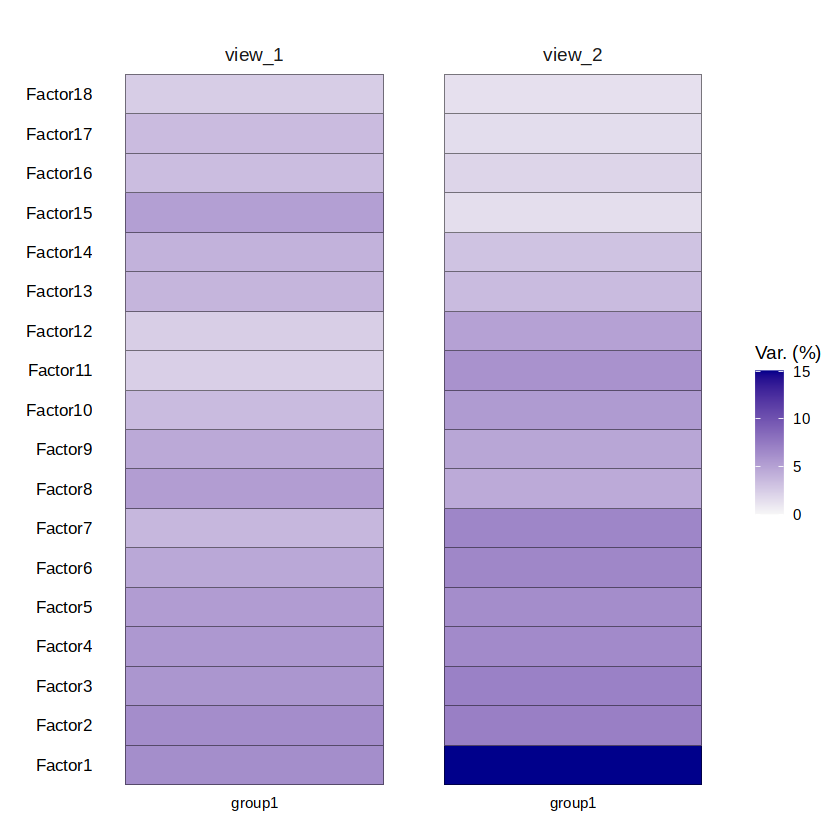

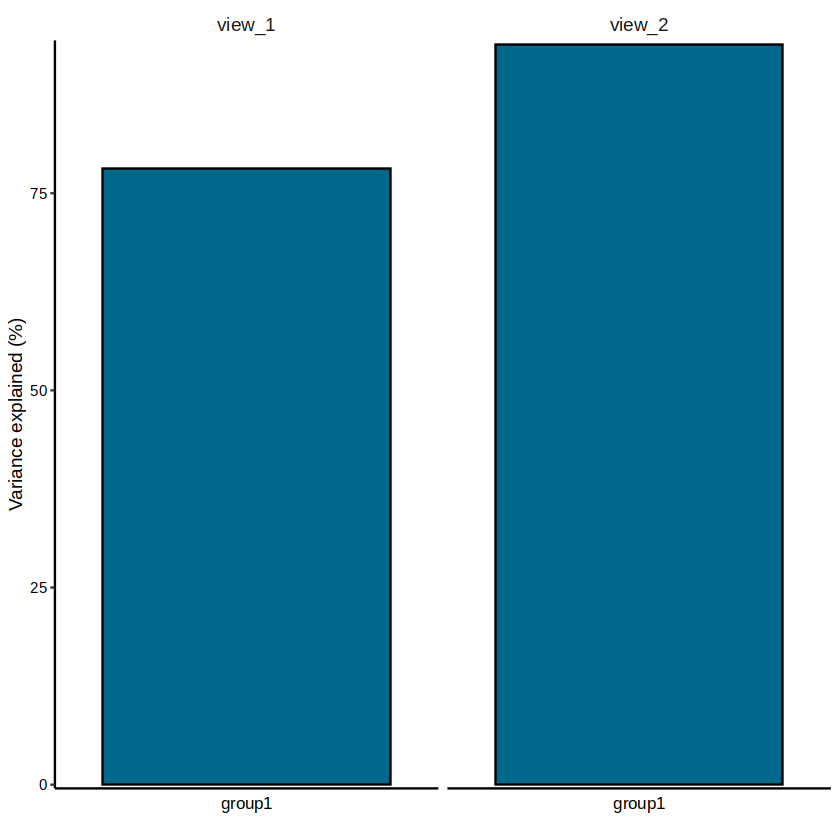

In [98]:
plot_variance_explained(MOFAobject.trained, x="group", y="factor", plot_total = T)

In [99]:
factors <- get_factors(MOFAobject.trained, factors = "all")

In [100]:
head(factors$group)

,Factor1,Factor2,Factor3,Factor4,Factor5,Factor6,Factor7,Factor8,Factor9,Factor10,Factor11,Factor12,Factor13,Factor14,Factor15,Factor16,Factor17,Factor18
RBG43471#AAACAGCCAACACTTG-1,-0.5440029,1.32332706,-0.09532250,-0.4209811,1.0657172,0.9747231,0.4202633,0.9914584,0.1347318,-0.8363026,1.0371770,-0.82253021,0.6728557,0.47531444,-0.5345196,0.9807484,0.56316394,-0.69028544
RBG43471#AAACAGCCACATACTG-1,-0.6492591,0.69685435,-0.56458890,-0.4536280,0.6259109,0.1635296,-1.2209117,1.0820866,-0.2655766,0.1493237,-1.7397401,0.28829369,-1.7239748,0.26018661,0.1799121,-0.9189627,0.98864919,0.37362561
RBG43471#AAACAGCCACGAATTT-1,-0.6605893,0.86558020,-0.62232971,-0.3456446,0.1369227,0.2755934,1.6016958,0.8015853,-1.4349749,0.4768839,-1.0847859,-0.17089559,0.7109873,1.61811888,-0.2301791,0.7493972,0.60406649,0.67712516
RBG43471#AAACAGCCAGTTAGCC-1,-0.5177121,0.51999009,-0.64247674,-0.5336225,0.4886442,-0.3852328,-2.0762165,1.5088027,1.5294156,0.7864240,-1.9834327,0.57804811,-1.8375974,-0.36953938,0.3650796,-0.3136618,0.42247880,0.73633039
RBG43471#AAACATGCAAGTCGCT-1,-0.8852600,-0.09158348,-0.78284878,-0.0504989,0.4199351,0.1180994,0.1941564,-1.2277416,-0.6414077,-0.6756843,-0.6972638,0.83481210,-0.3536631,-0.30006337,0.3611409,0.3677174,2.04325318,0.09327159
RBG43471#AAACATGCAATTGAAG-1,-0.8605986,0.34313989,0.04129433,-0.3897128,1.0272853,1.3159901,-1.1646743,0.9064465,0.7018546,0.5083026,-0.4534084,0.04007871,-3.1255100,-0.02435427,0.3397456,0.5882390,-0.03343424,-0.43020007


In [103]:
plots = lapply(1:18, function(x){
    p = ggplot(cbind(sample_metadata, factors$group), aes_string('genotype', paste0('Factor', x))) + 
            geom_violin() + 
            geom_boxplot(width=0.2, outlier.shape=NA) +
            theme_bw()
})

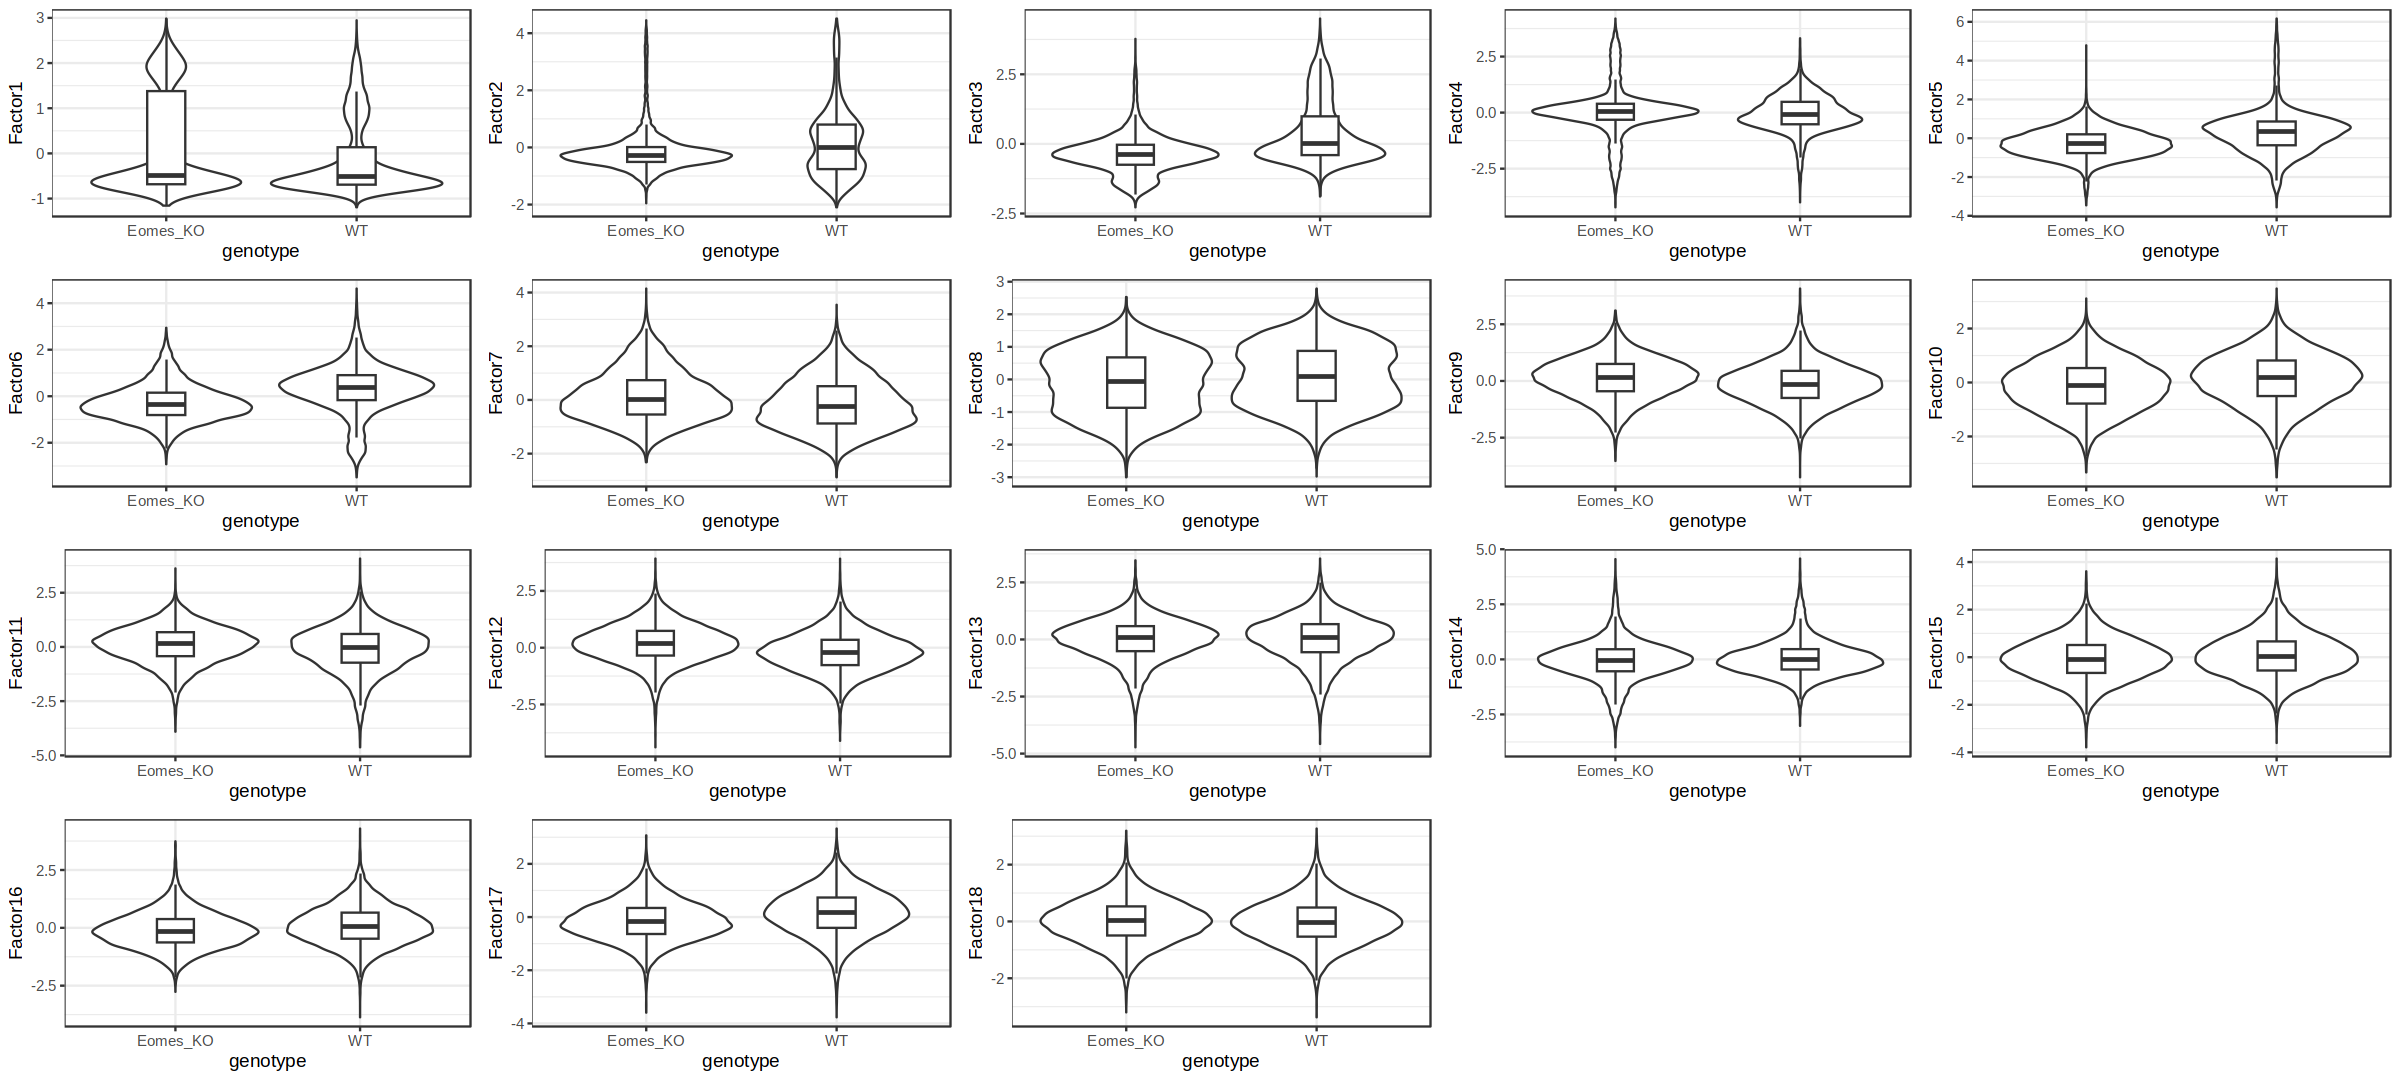

In [107]:
options(repr.plot.width=20, repr.plot.height=9)
ggarrange(plotlist=plots)

In [161]:
umap = uwot::umap(factors$group1, n_neighbors = 25, min_dist = 0.15)

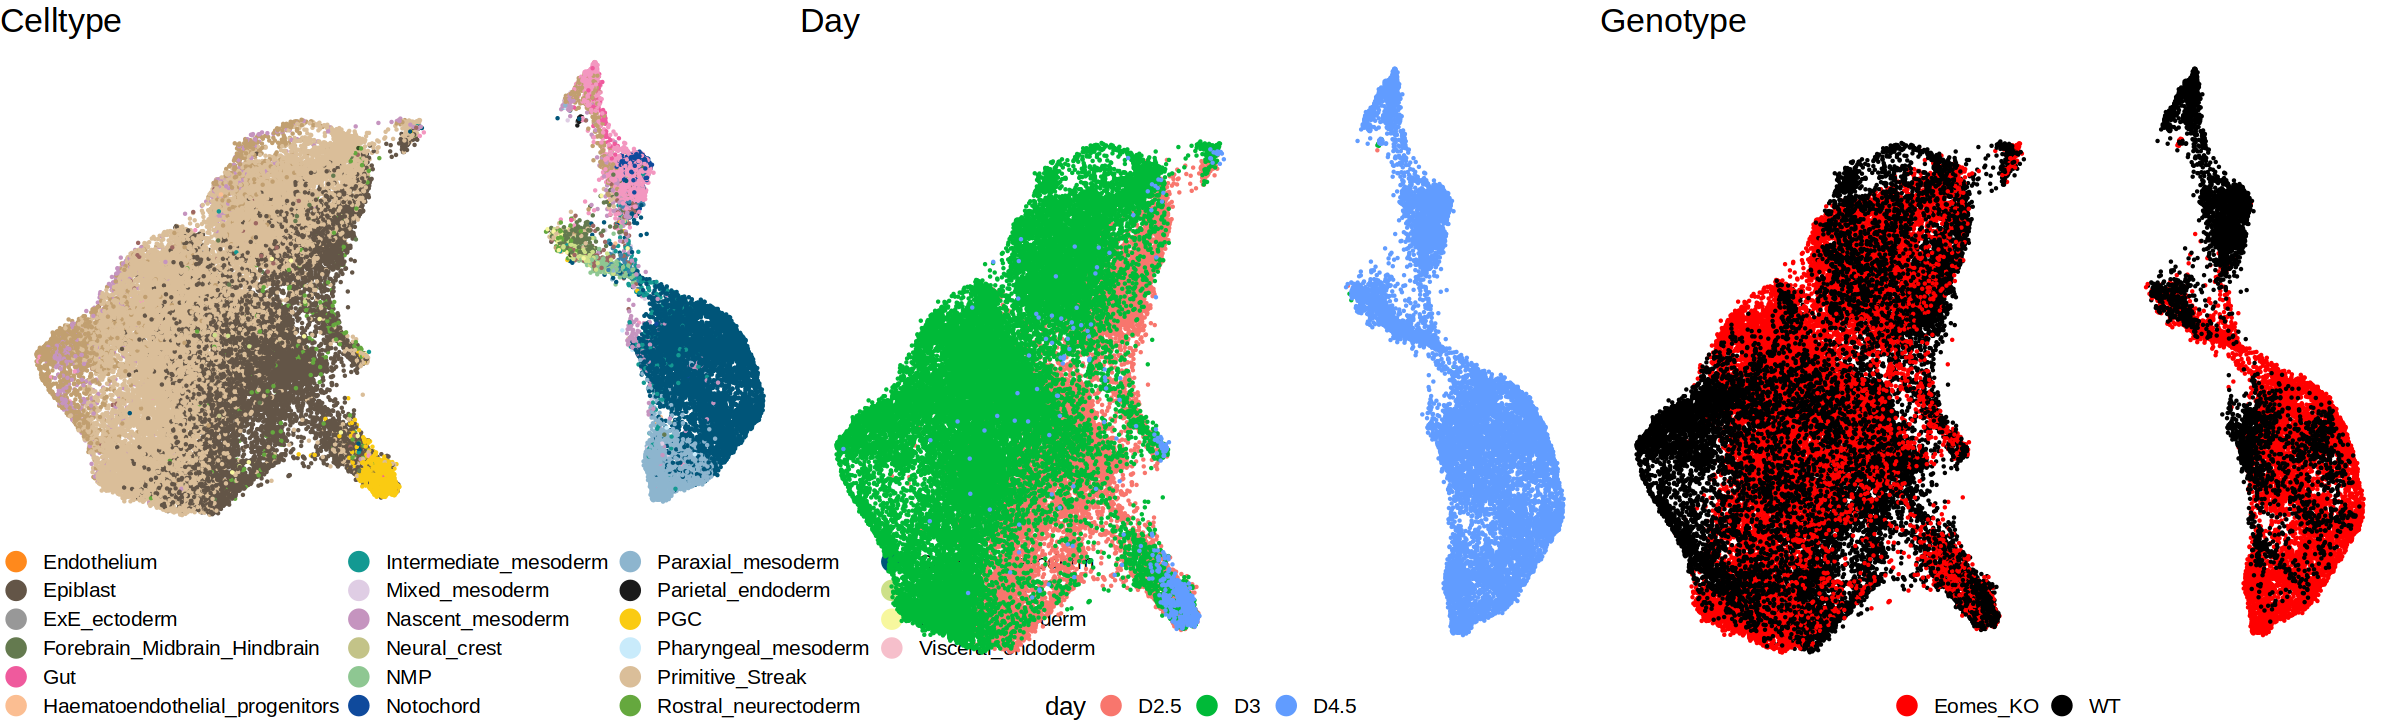

In [162]:
umap.dt = as.data.table(umap, keep.rownames=T) %>%
    setnames(c('cell', 'UMAP1', 'UMAP2')) %>%
    .[, UMAP2:=UMAP2*-1] %>% # flip umap2 for consistency
    merge(., sample_metadata, by='cell')

options(repr.plot.width=25, repr.plot.height=9)
plot_umap(umap.dt)

In [163]:
fwrite(as.data.table(factors$group1, keep.rownames=T) %>% setnames('rn', ' cell'), sprintf('%s/MOFA_factors.txt.gz', args$outdir))

In [164]:
fwrite(umap.dt[,c('cell', 'UMAP1', 'UMAP2')], sprintf('%s/MOFA_umap.txt.gz', args$outdir))

In [165]:
pdf(sprintf('%s/MOFA_umap.pdf', args$outdir), width=15, height=5)
    plot_umap(umap.dt)
dev.off()

png 
  2

In [166]:
umap.dt = fread(sprintf('%s/MOFA_umap.txt.gz', args$outdir))

In [167]:
plots = mclapply(1:18, function(x){
    to.plot = cbind(umap.dt, factors$group)
    p = ggplot(to.plot, aes_string('UMAP1', 'UMAP2', col = paste0('Factor', x))) + 
        geom_point(size=0.2) + 
        scale_color_gradient2(low='blue', mid='lightyellow', high='red') +
        theme_void() +
        theme(text=element_text(size=15), 
             plot.title=element_text(size=15), 
             legend.position='none')
}, mc.cores=22)

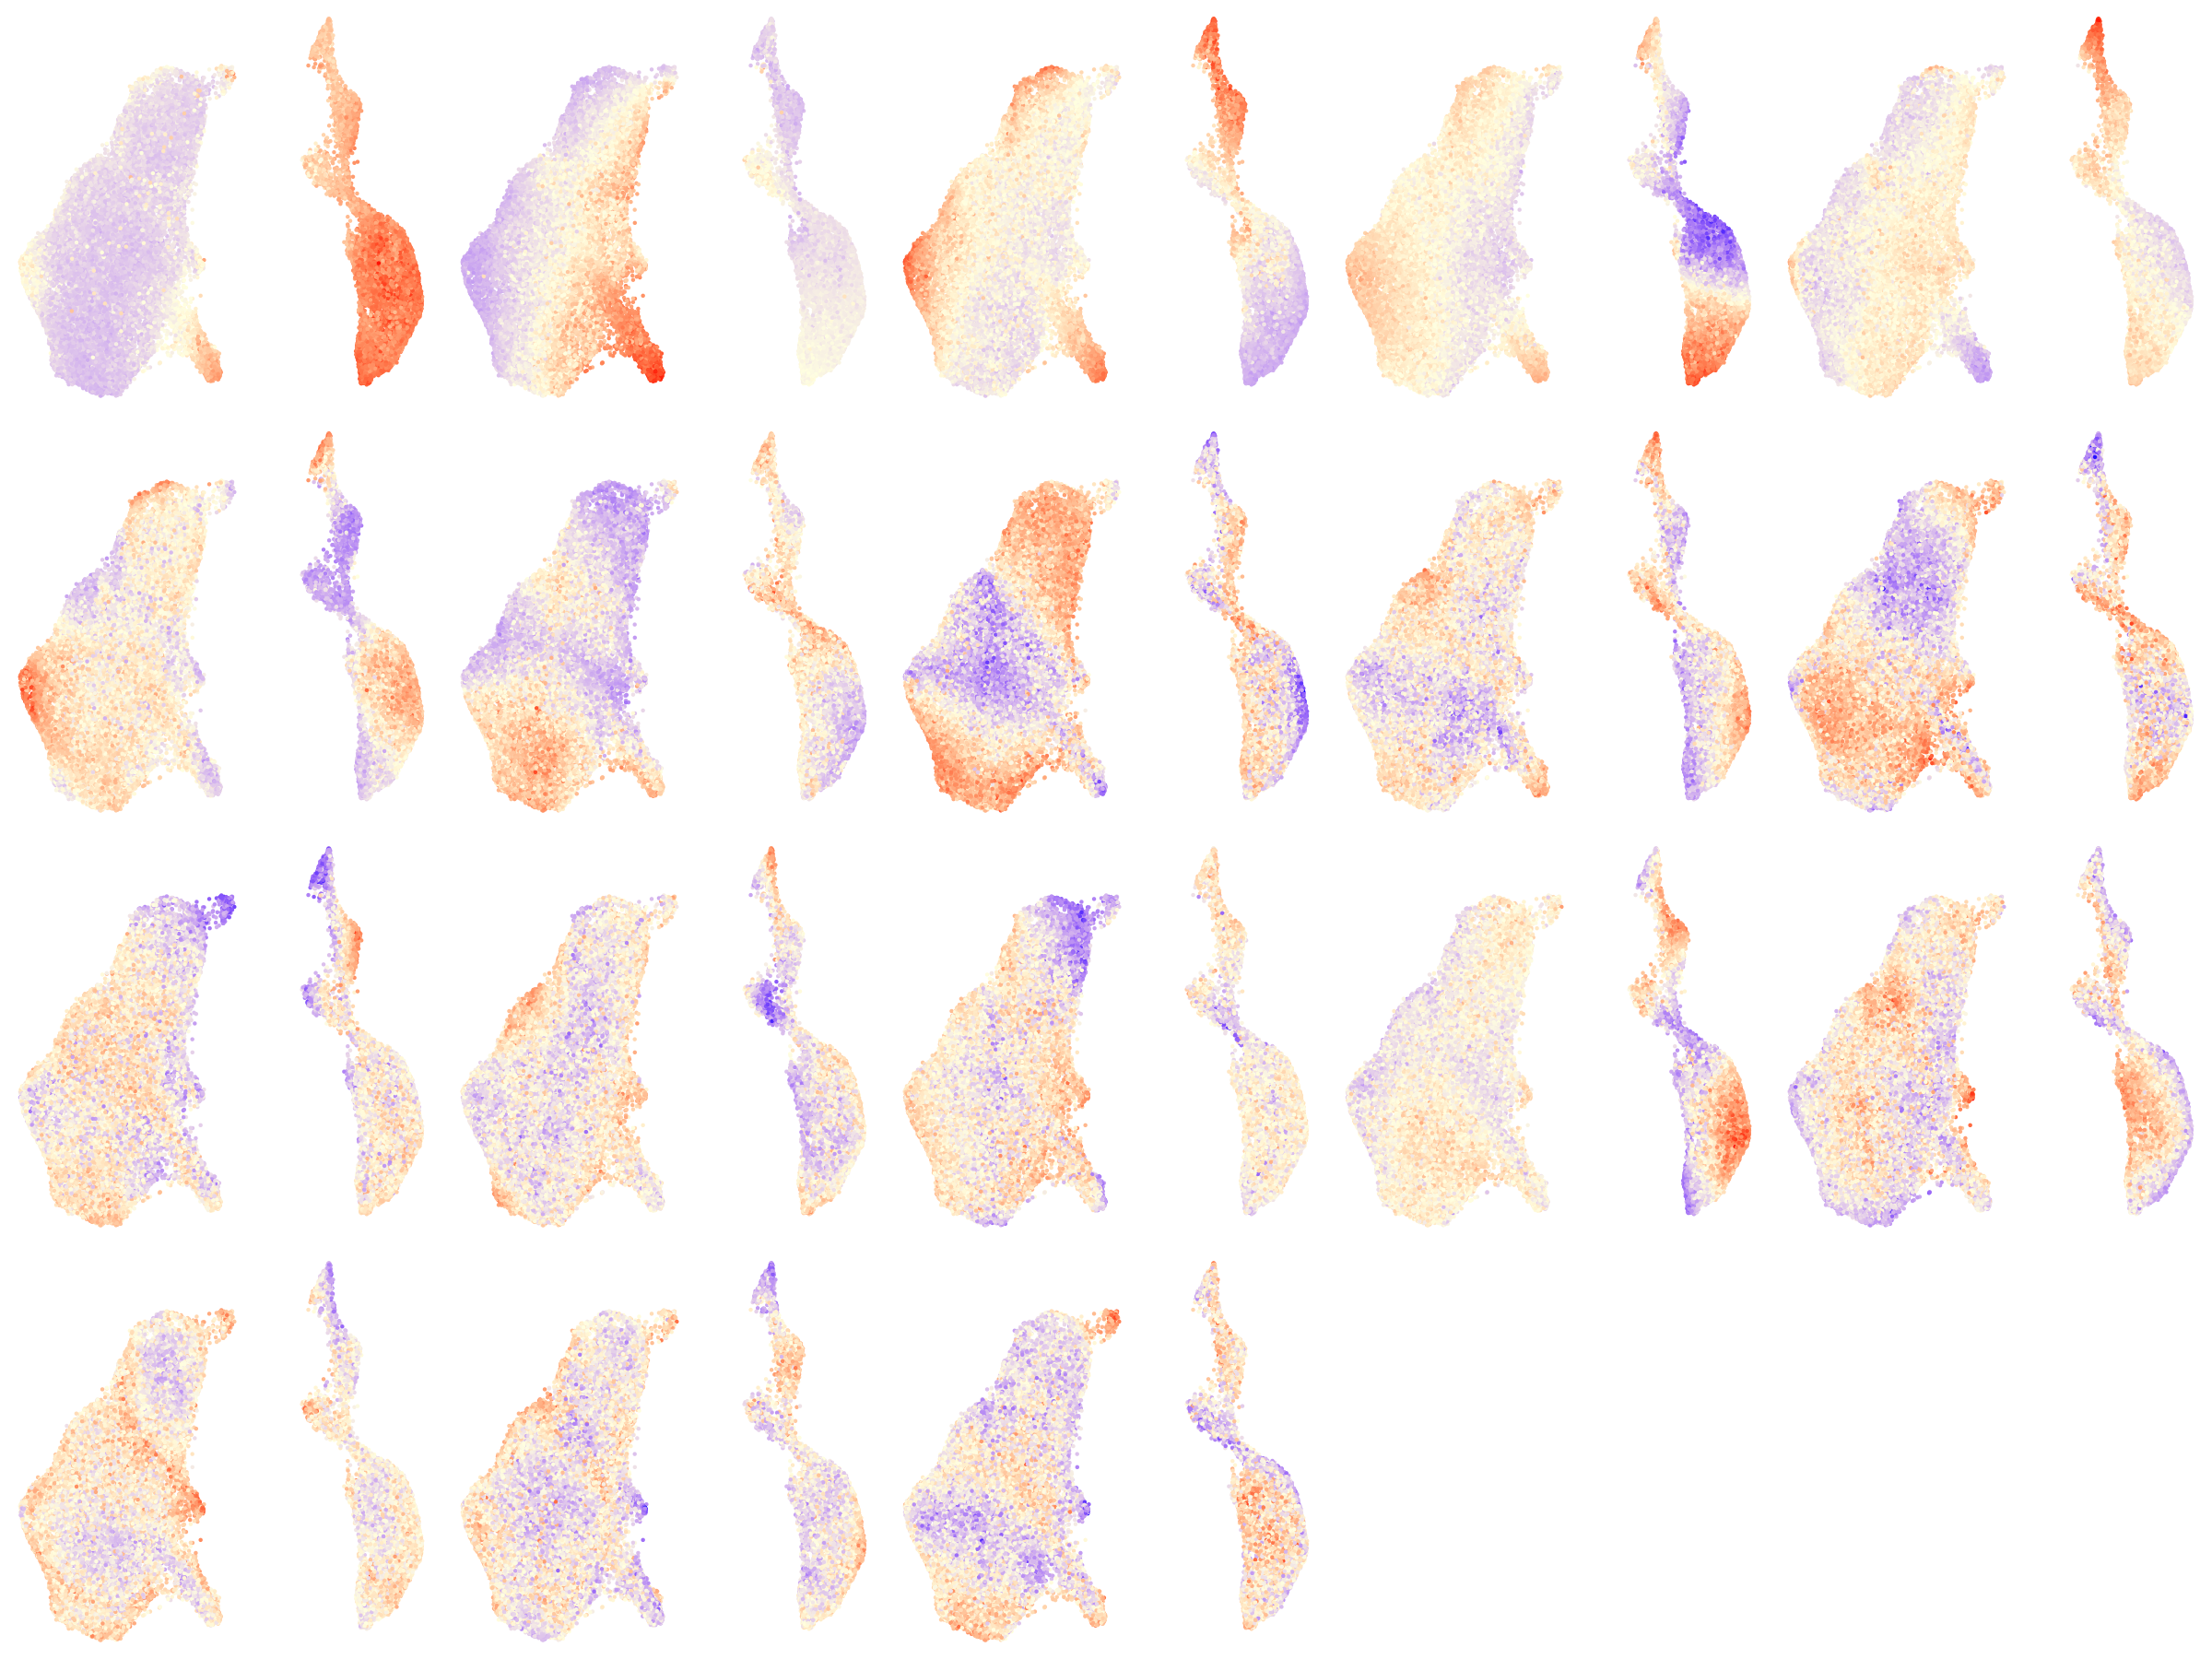

In [168]:
options(repr.plot.width=20, repr.plot.height=15)
ggarrange(plotlist=plots)